# Random Forest — Resumen visual
### Predicción del Éxito Académico en Educación Superior



**Modelo:** Random Forest (`sklearn.ensemble.RandomForestClassifier`)  
**Tipo:** Ensemble de 300 árboles de decisión con bagging + selección aleatoria de features  
**Criterio de split:** Impureza Gini — la misma métrica que genera la feature importance  
**Estrategia de selección:** `GridSearchCV` con validación cruzada 5-fold  
**Hiperparámetros:** n_estimators ∈ {100,300} × max_features ∈ {sqrt,20} × max_depth ∈ {20,None} → 40 entrenamientos  
**Desbalanceo:** `class_weight='balanced'` — mismo mecanismo que en Regresión Logística  
**Métrica objetivo:** Macro F1-score  
**Resultado óptimo:** `n_estimators=300`, `max_features=20`, `max_depth=20` → Macro F1 test = **0.700**


---
## 1. Búsqueda de hiperparámetros — Heatmap CV

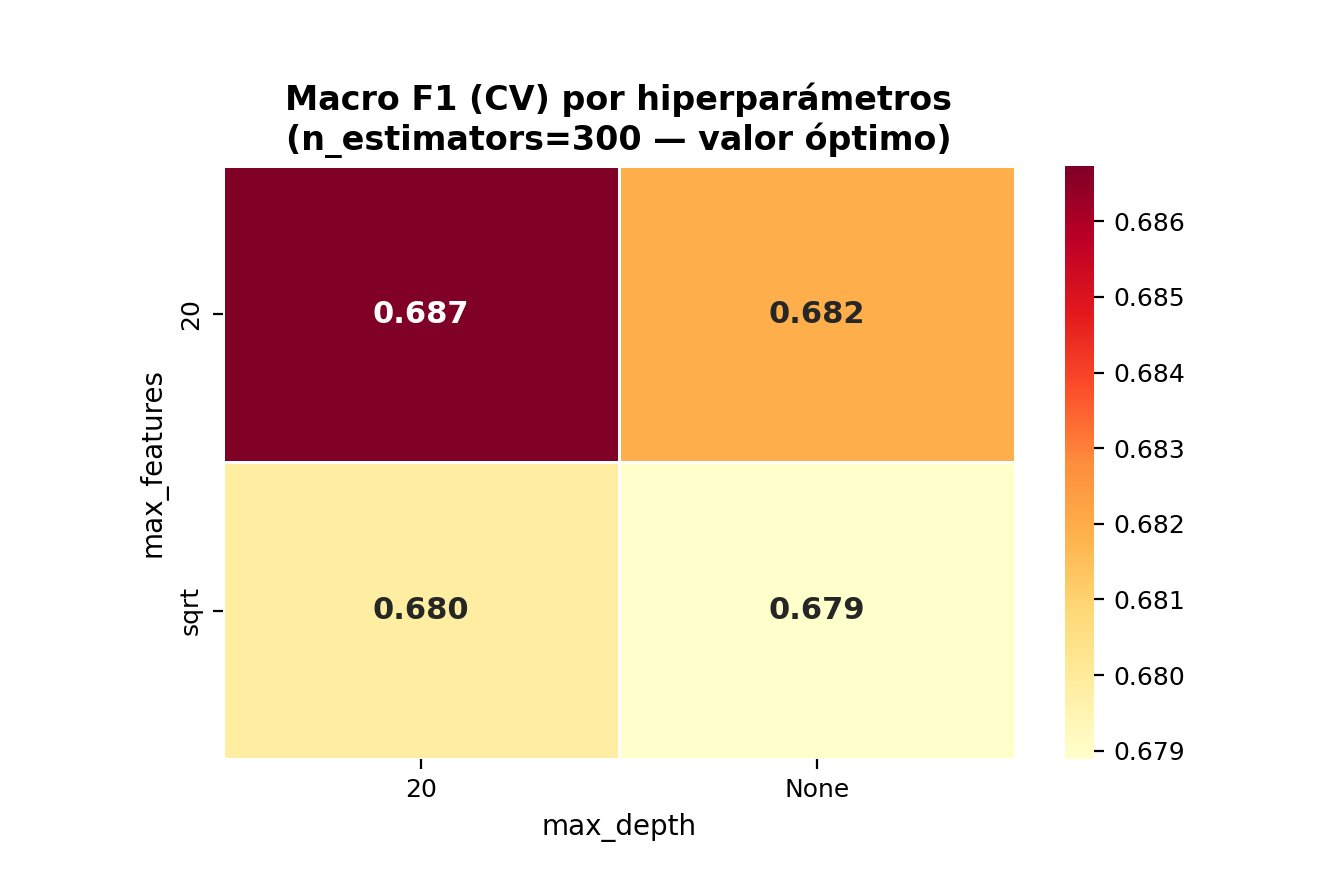


> Fijamos como valor óptimo de n_estimators = 300 ya que hemos visto que no supone una enorme capacidad computacional y tener más árboles mejora el problema de la varianza. Por tanto nos queda entender cómo se seleccionan los otros dos hiperparámetros. El heatmap nos permite ver las cuatro combinaciones posible con sus respectivos Macro F1 score obtenido trás realizar cross-validation con k= 5 folds

> Vemos que los valores de Macro F1 score son muchos más cercanos en este modelo que con KNN o Regresión logística. Eso se explica ya que en Random Forest los hiperparámetros no controlan el mecanismo fundamental del modelo sino parámetros secundarios de un ensemble que ya tiene su propia estabilidad inherente. El ensemble es un amortiguador de las diferencias de configuración

> Vemos que el parámetro óptimo de max_features es 20. Esto tiene sentido sobre todo en un dataset con alta colinealidad entre variables como hemos podido verificar en modelos anteriores. Si max_features fuese 10, tendríamos menos variables por split y por tanto existe bastante probabilidad de que entren en consideración varias variables correlacionadas provocando árboles demasiado parecidos que no corrigen correctamente el problema de sesgo que aporta esta alta correlación de nuestro dataset en variables académicas.

> Por último vemos que se selecciona max_depth = 20 en vez de None. Con "None", los árboles crecen mucho capturando patrones muy ruidosos y generalizan muy mal. Si hiciésemos bagging normal este efecto sobre cada árbol individual se compensaría porque se promedia sobre muchos árboles sobreajustados pero aquí se suma otro factor adicional: matriculado tiene solo 519 muestras en train, que es la clase más difícil. Los árboles sin límite tienden a crear hojas muy específicas para matriculado que en test no se activan ya que los alumnos de test no coinciden exactamente con esos patrones tan específicos captados en train. Por ello, limitar a 20 preguntas binarias por árbol permite que cada hoja represente una región suficientemente ampli del espacio como para generalizar.


---
## 2. Matriz de confusión (normalizada por fila)

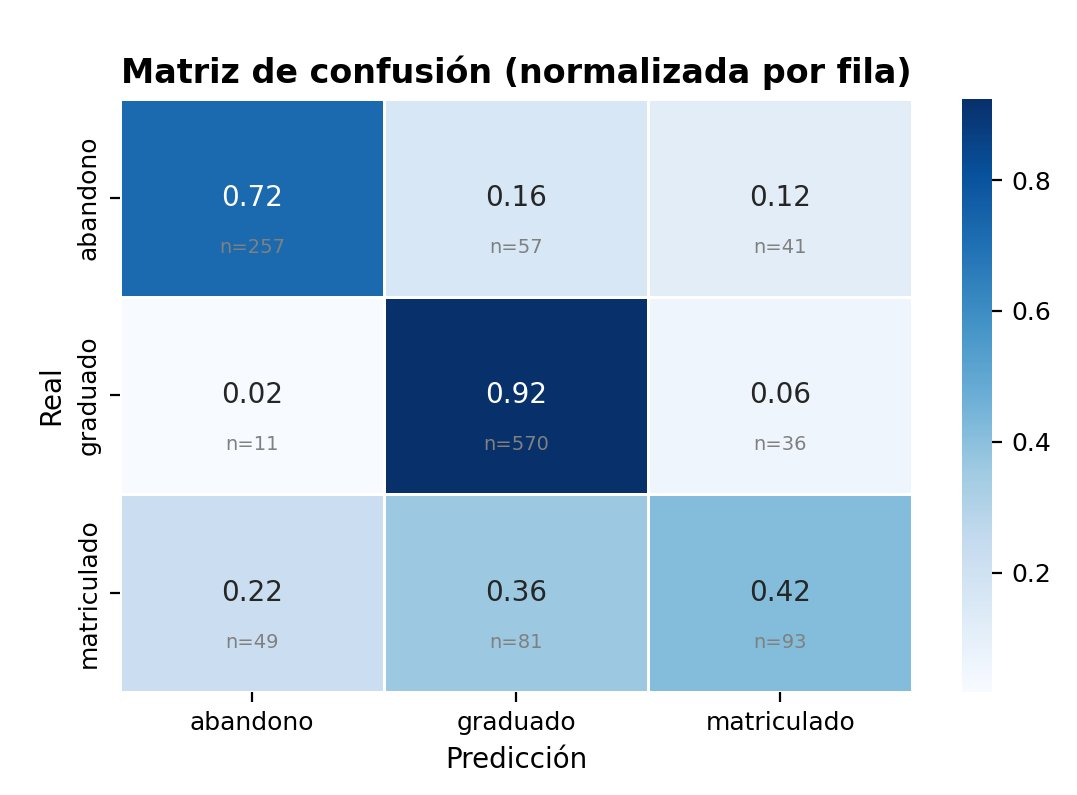

**Evolución respecto a los modelos anteriores — fila a fila:**
> Vemos que "abandono" recupera el recall= 0.72 alto como el que obtuvimos en regresión logística. Esto ocurre a que ya no producimos el sesgo que generó KNN hacia la categoría "graduado".
> En "graduado"obtenemos el mejor recall de los tres modelos ya que con Random Forest conseguimos sobrepasar la limitación de solo captar patrones lineales. Nuestro modelo RandomForest distingue mucho mejor entre graduados y matriculados lo que nos hace pensar que entre esas clases existen patrones no lineales que mejoran los resultados cuando podemos captarlos.
> En "matriculado" ocurre algo que nos sorprende bastante, obtenemos peor recall que en regresión logística. Es verdad que los errores se distribuyen mejor entre "graduado" y "abandono".

**¿Por qué RF clasifica peor `matriculado` que RL a pesar de ser más potente?**
> Esto ocurre debido a que cuando hacemos class_weight = "balanced" en regresión logística, penalizamos los fallos en matriculado durante todo el ajuste. Sin embargo, en RandomForest ese mismo parámetro actúa dentro de cada árbol invidual pero al usar un ensemble con 300 árboles se suaviza el efecto. Por tanto, ese efecto de promediado que ayudaba a una mejor generalización del modelo nos pasa factura al querer luchar contra el desbalanceo de clases.



---
## 3. Métricas comparativas — Los tres modelos

**Tabla resumen — Macro F1 global y F1 por clase (valores reales sobre test):**

| | **Reg. Logística** | **KNN** | **Random Forest** |
|---|---|---|---|
| **Macro F1 (CV — selección)** | 0.706 | 0.561 | 0.687 |
| **Macro F1 (test final)** | **0.714** | 0.584 | 0.700 |
| **Accuracy (test)** | 0.713 | 0.685 | **0.770** |
| | | | |
| F1 `abandono` | 0.764 | 0.623 | 0.765 |
| F1 `graduado` | 0.840 | 0.795 | **0.860** |
| F1 `matriculado` | **0.537** | 0.334 | 0.473 |

**¿Por qué el modelo más complejo no consigue el mayor Macro F1?**
> Comparando con los macro F1 en el test final en los tres modelos vemos que Random Forest no obtiene el mejor resultado. Eso se explica por el comportamiento obtenido sobre la clase "matriculado" en nuestro modelo Random Forest. Un modelo por tanto más complejo no va implicar necesariamente mejor Macro F1.

**¿Qué limitaciones de los modelos anteriores ha solucionado RF?**
> Hemos podido arreglar el problema del sesgo geométrico de KNN ya que con Random Forest no trabajamos con distancias locales por lo que la densidad mayor de graduado en el espacio de features no arrastra los votos.

> También hemos solucionado la limitación de regresión logística de capturar patrones solo lineales entre features. Consiguiendo sobrepasar esta limitación con Random Forest damos un salto considerable en "graduado" que nos chiva que había combinaciones de variables que separan "graduado" de no-graduado que eran no lineales y que no podíamos tratar correctamente con regresión logística.

> Conseguimos también regular el problema de colinealidad de las variables. En regresión logística se hacía automáticamente con Lasso y ahora se hace también gracias a la selección aleatoria de features en cada split a la hora de hacer crecer los árboles. Esto también se refleja en los resultados de variable importance que veremos después

**¿Qué le ha penalizado para quedar por debajo de RL en Macro F1?**

> Hemos conseguido solucionar los problemas que iban surgiendo de los modelos anteriores y aún así no obtenemos el mejor Macro F1 score en test. Este comportamiento ocurre por el comportamiento que toma "class_weight=balanced" en este tipo de modelos de ensemble. En regresión logística modifica la función de pérdida de manera global durante todo el ajuste mientras que en Random Forest actúa individualmente dentro de cada árbol y por tanto ese efecto de dilución típico de modelos de ensemble juega en contra reduciendo nuestra capacidad de gestionar el desbalanceo de clases con esta técnica.
> La consecuencia es que se baja el recall en matriculados al ser minoritarios en el dataset. En resumen, Random Forest funciona mejor para encontrar graduados y más preciso cuando se trata de predecir matriculados pero regresión logística es mejor encontrando matriculados reales y en macro F1 encontrar los matriculados (recall) pesa tanto como encontrar los graduados.


---
## 4. Feature Importance — Importancia global del modelo

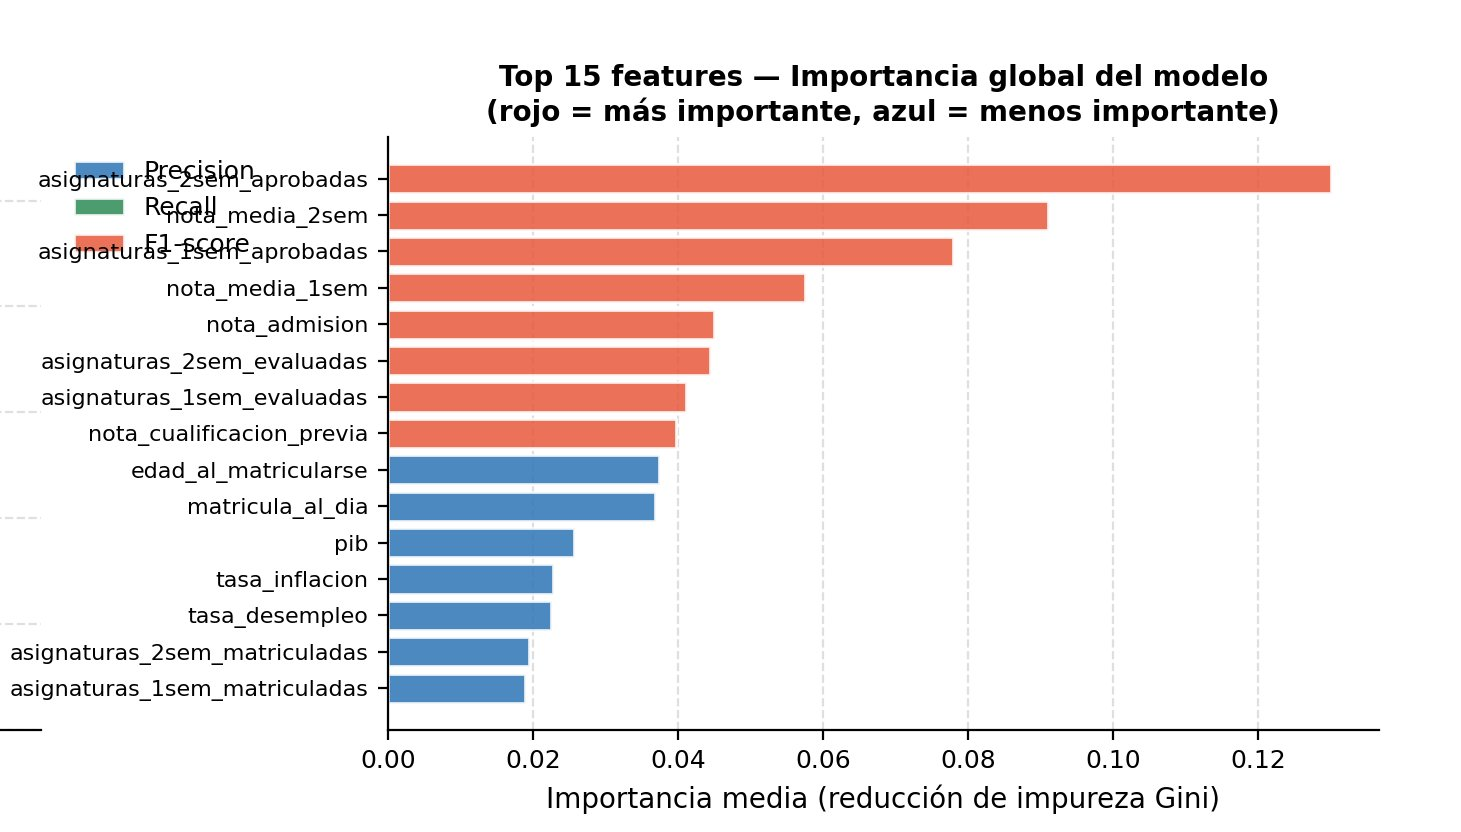

**¿Qué mide la feature importance y en qué se diferencia de los coeficientes de RL?**

> Podemos medir por cada feature su variable importance que se define como la reducción media de impureza Gini que produce cada feature en todos los splits de los 300 árboles. En regresión logística ya habíamos analizado los coeficientes obtenidos para matriculado pero la gran diferencia con analizar los coeficientes de regresión logistica son: siempre positiva (mide relevancia no dirección), no lineal (captura interacciones que regresión logística no puede modelar) y global (promedia sobre todo el ensemble y todas las clases)

**Coherencia con el análisis de colinealidad y los coeficientes de RL:**

> En regresión logística solo hicimos un análisis de los coeficientes de la clase matriculado. Sin embargo, lo que sí vemos es que asignaturas_2sem_aprobadas vuelve a ser la variable asignada como la más discriminativa del problema. Hemos podido ver como dos modelos con filosofías distintas coinciden en señalar esa misma variable!

> Vemos que nota_admision aparece con importancia relevante mientras que en regresión logística no aparecía como coeficiente relevante en matriculado. Por tanto queda abierta la pregunta de si esa importancia viene de patrones lineales con otras clases que simplemente no hemos visualizado en el modelo de regresión lineal o si son de interacciones no lineales que solo se podían captar gracias a la implementación de este modelo.

>En la parte baja del ranking vemos reflejada esa idea de colinealidad de algunas features relacionadas con el rendimiento académico. Las asignatures de 2sem y 1sem matriculadas tienen variable importance muy similar lo que nos deja entrever algo que ya sabíamos que es esa redundancia para algunas features

---
## 5. Comparativa final — Los tres modelos de clasificación

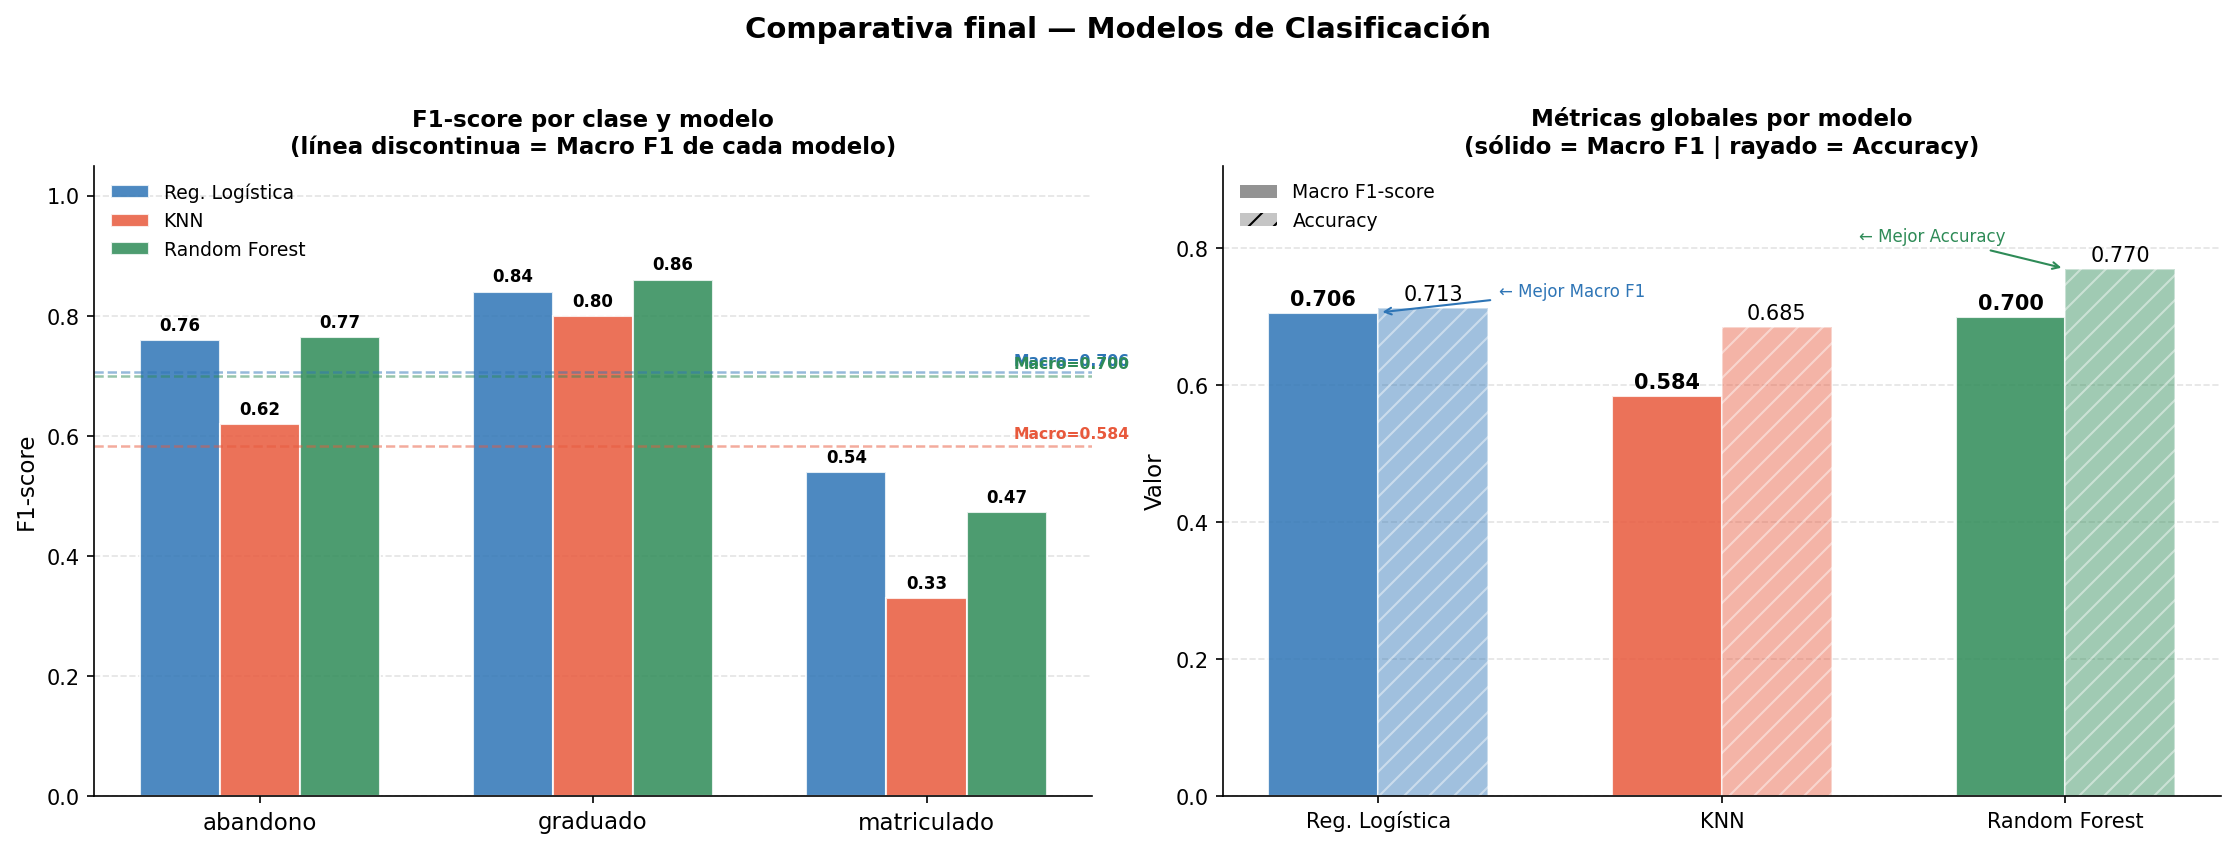

**¿Qué muestra cada panel?**

> - **Panel izquierdo:** F1-score por clase y modelo. Las líneas discontinuas muestran el Macro F1 de cada modelo. Permite ver de un vistazo qué clase explica las diferencias entre modelos.
> - **Panel derecho:** Macro F1 y Accuracy globales. Las barras sólidas son Macro F1 (métrica principal) y las rayadas son Accuracy. La divergencia entre ambas métricas en RF es especialmente reveladora.

**Las tres conclusiones clave que cierra esta comparativa:**

> 1. Regresión logística obtiene el mejor Macro F1 en test mientras que Random Forest obtiene mejor resultado en Accuracy. Esto se explica debido a que Random Forest ha clasificado mejor los graduados que son la clase dominante pero ha fallado más en matriculado y Macro F1 penaliza por igual ese desquilibrio

> 2.  La manera en la que la clase "matriculado" ha sido tratado por los distintos modelos es lo que provoca esa diferenciación clara entre resultados. Hemos entendido que reside fundamentalmente en una característica estructural del problema que puede ser usada aún más en contra en modelos como KNN



---
## 5. Conclusión — Random Forest


<div style="border: 2px solid #2e86c1; border-radius: 8px; padding: 20px 24px; margin: 28px 0; background-color: #eaf4fb; color: #000000;">
<h3 style="color: #1a5276; margin-top: 0; padding-bottom: 8px; border-bottom: 1px solid #aed6f1; margin-bottom: 14px;">Conclusiones finales — Random Forest</h3>

Conclusiones finales trás el análisis de los resultados en el notebook:
El modelo Random Forest con n_estimators=300, max_features=20 y max_depth =20 obtiene un Macro F1 de 0.7 en test que es prácticamente igual que regresión logística (0.714) pero con un accuracy algo superior. La selección de max_features=20  refleja la alta colinealidad del dataset: con solo 10 features por split existe probabilidad de que el subconjunto esté dominado por features con alta correlación  mientras que 20 features genera un comportamiento distinto óptimo en nuestro caso. Con 20 features cada split individual toma decisiones menos sesgadas por la colinealidad porque tiene más probabilidad de ver features de distintos bloques semánticos. Por tanto, cada árbol es más informativo a costa de que los árboles se correlacionen algo más entre sí. En nuestro caso ese trade-off sale favorable porque el beneficio de hacer mejores splits supera el coste de tener árboles algo más parecidos. Además, la profundidad limitada a 20 actúa como regularización suave.
Gracias al análisis en el notebook nos hemos dado cuenta de que Random Forest resuelve los dos problemas estructurales identificados en los modelos anteriores: elimina el sesgo geométrico de KNN al no trabajar con distancias locales y supera la linealidad de la regresión logística capturando patrones no lineales del dataset que elevan especialmente el F1  de "graduado" a 0.860. La selección aleatoria de features regula además la colinealidad de forma implícita y el modelo nos permite calcular el variable importance de las distintas variables para terminar concluyendo que asignaturas_2sem_aprobadas lidera el ranking siendo la variable más discriminativa (algo que pudimos ver ligeramente en regresión logística al analizar los coeficientes de matriculados).
Sin embargo, el mecanismo class_weight = "balanced" pierde efectividad en ensemble: en Regresión Logística modifica la función de pérdida globalmente durante todo el ajuste mientras que en Random Forest actúa árbol por árbol y el promediado diluye su efecto.  Esto nos muestra también cómo la  propiedad promediadora del ensamble que es tan útil para mejorar el rendimiento también puede jugarnos una mala pasada si no tenemos en cuenta el comportamiento de todo lo que usamos durante el modelado. Esto termina demostrando que mayor complejidad de modelo no garantiza mejor Macro F1 cuando la métrica penaliza por igual las tres clases y el desbalance no se gestiona con igual eficacia.


</div>